In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **LOAD DATA**

In [4]:
df = pd.read_csv('D:\Kuliah\CAWU 5\Data Mining\data-mining\datasets\paysim-dataset.csv')

Deskriptif Statistik

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.shape

(6362620, 11)

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Tipe Data:

In [8]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Cek Missing Value

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

cek duplikat

In [11]:
df.duplicated().sum()

np.int64(0)

Analisis fraud berdasarkan jenis transaksi (TRANSFER, CASH_OUT, dll)

In [12]:
df.groupby("type")["isFraud"].agg(["sum", "count", "mean"])

,sum,count,mean
type,,,
CASH_IN,0,1399284,0.000000
CASH_OUT,4116,2237500,0.001840
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000
TRANSFER,4097,532909,0.007688


semua transaksi yang amount = 0

In [13]:
df[df["amount"] == 0]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0,C1510987794,0.0,0.0,C1696624817,0.00,0.00,1,0
3247298,250,CASH_OUT,0.0,C521393327,0.0,0.0,C480398193,0.00,0.00,1,0
3760289,279,CASH_OUT,0.0,C539112012,0.0,0.0,C1106468520,538547.63,538547.63,1,0
5563714,387,CASH_OUT,0.0,C1294472700,0.0,0.0,C1325541393,7970766.57,7970766.57,1,0
5996408,425,CASH_OUT,0.0,C832555372,0.0,0.0,C1462759334,76759.90,76759.90,1,0
5996410,425,CASH_OUT,0.0,C69493310,0.0,0.0,C719711728,2921531.34,2921531.34,1,0
6168500,554,CASH_OUT,0.0,C10965156,0.0,0.0,C1493336195,230289.66,230289.66,1,0
6205440,586,CASH_OUT,0.0,C1303719003,0.0,0.0,C900608348,1328472.86,1328472.86,1,0
6266414,617,CASH_OUT,0.0,C1971175979,0.0,0.0,C1352345416,0.00,0.00,1,0
6281483,646,CASH_OUT,0.0,C2060908932,0.0,0.0,C1587892888,0.00,0.00,1,0


cek jumlah nilai transaksi yang negatif per kolom

In [14]:
cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
        "oldbalanceDest", "newbalanceDest"]

print((df[cols] < 0).sum())

amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64


In [15]:
# Origin (berdasarkan nameOrig)
orig_err_C = (df[df["nameOrig"].str.startswith("C")]
              ["oldbalanceOrg"].sub(df["amount"])
              .sub(df["newbalanceOrig"])
              .abs().gt(0.01).sum())

orig_err_M = (df[df["nameOrig"].str.startswith("M")]
              ["oldbalanceOrg"].sub(df["amount"])
              .sub(df["newbalanceOrig"])
              .abs().gt(0.01).sum())


# Destination (berdasarkan nameDest)
dest_err_C = (df[df["nameDest"].str.startswith("C")]
              ["oldbalanceDest"].add(df["amount"])
              .sub(df["newbalanceDest"])
              .abs().gt(0.01).sum())

dest_err_M = (df[df["nameDest"].str.startswith("M")]
              ["oldbalanceDest"].add(df["amount"])
              .sub(df["newbalanceDest"])
              .abs().gt(0.01).sum())


print("Origin error (C):", orig_err_C)
print("Origin error (M):", orig_err_M)
print("Destination error (C):", dest_err_C)
print("Destination error (M):", dest_err_M)

Origin error (C): 5077691
Origin error (M): 0
Destination error (C): 2037152
Destination error (M): 2151495


In [16]:
print(df[df['nameDest'].str.startswith('M')]['oldbalanceDest'])

0          0.0
1          0.0
4          0.0
5          0.0
6          0.0
          ... 
6362312    0.0
6362314    0.0
6362316    0.0
6362318    0.0
6362319    0.0
Name: oldbalanceDest, Length: 2151495, dtype: float64


In [17]:
print(df[df['nameDest'].str.startswith('M')]['isFraud'])

0          0
1          0
4          0
5          0
6          0
          ..
6362312    0
6362314    0
6362316    0
6362318    0
6362319    0
Name: isFraud, Length: 2151495, dtype: int64


In [18]:
print("Name Prefix Analysis:")
print(f"nameOrig unique prefixes : {df['nameOrig'].str[0].unique()}")
print(f"nameDest prefix counts   :")
print(df["nameDest"].str[0].value_counts())

Name Prefix Analysis:
nameOrig unique prefixes : ['C']
nameDest prefix counts   :
nameDest
C    4211125
M    2151495
Name: count, dtype: int64


Q1=13389.57, Q3=208721.48, IQR=195331.91
Upper fence (IQR)=501719.34
IQR outliers: 338078 (5.31%)
99.9th percentile=8956797.68
>99.9% count: 6363


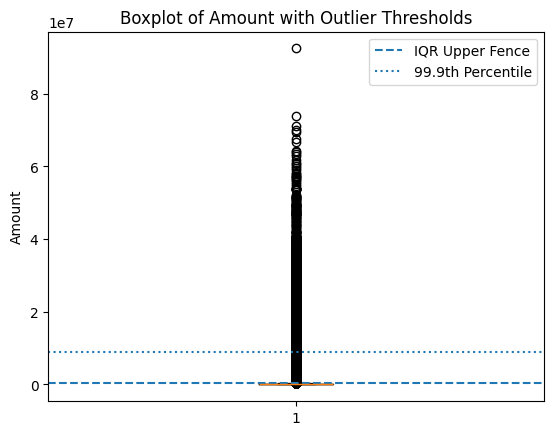

In [19]:
import matplotlib.pyplot as plt

Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

p999 = df["amount"].quantile(0.999)

iqr_outliers = (df["amount"] > upper_fence).sum()
p999_outliers = (df["amount"] > p999).sum()

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Upper fence (IQR)={upper_fence:.2f}")
print(f"IQR outliers: {iqr_outliers} ({iqr_outliers/len(df)*100:.2f}%)")
print(f"99.9th percentile={p999:.2f}")
print(f">99.9% count: {p999_outliers}")

plt.figure()
plt.boxplot(df["amount"])
plt.axhline(upper_fence, linestyle='--', label='IQR Upper Fence')
plt.axhline(p999, linestyle=':', label='99.9th Percentile')

plt.title("Boxplot of Amount with Outlier Thresholds")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [20]:
df[(df['isFlaggedFraud']==0) & (df['isFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


##**Univariate Visualization**

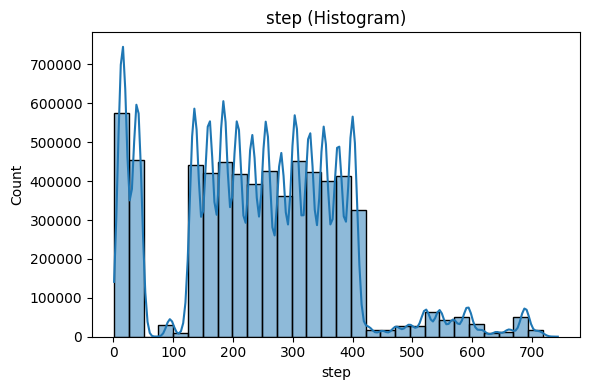

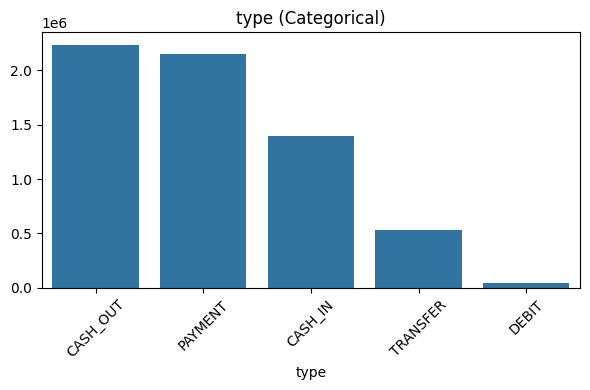

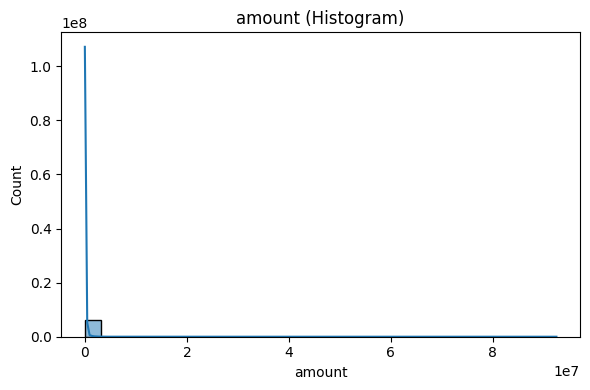

In [ ]:
def plot_auto(df):
    for col in df.columns:
        unique_count = df[col].nunique()

        plt.figure(figsize=(6,4))

        # CASE 1: categorical (unique < 15)
        if unique_count < 15:
            value_counts = df[col].value_counts()

            sns.barplot(
                x=value_counts.index,
                y=value_counts.values
            )

            plt.title(f"{col} (Categorical)")
            plt.xticks(rotation=45)

        # CASE 2: numerical / many unique
        else:
            # drop NaN biar aman
            sns.histplot(df[col].dropna(), bins=30, kde=True)

            plt.title(f"{col} (Histogram)")

        plt.tight_layout()
        plt.show()

plot_auto(df)

##**Data Cleaning**

In [ ]:
cleaning_log = []

In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
removed = before - len(df)
cleaning_log.append(f"Duplicates removed : {removed}")
print(f"Duplicates removed: {removed}")

In [ ]:
before = len(df)
df = df[df["amount"] > 0].copy()
removed = before - len(df)
cleaning_log.append(f"Zero-amount rows removed : {removed} (all were isFraud=1 CASH_OUT simulator artifacts)")
print(f"Zero-amount rows removed: {removed}")

In [ ]:
df.drop(columns=["isFlaggedFraud"], inplace=True)
cleaning_log.append("Dropped 'isFlaggedFraud' : 0.19% recall, subset of isFraud — not predictive")
print("Dropped column: isFlaggedFraud")

In [ ]:
df.drop(columns=["nameOrig"], inplace=True)
cleaning_log.append("Dropped 'nameOrig' : zero entropy (all 'C' prefix), transaction ID only")
print("Dropped column: nameOrig")

In [ ]:
df.shape

##**Feature Engineering**

In [ ]:
df["balanceDiffOrig"] = df["newbalanceOrig"] - df["oldbalanceOrg"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [ ]:
mask_no_activity = (
    (df["amount"] == 0) & # This condition will always be False now.
    (df["balanceDiffOrig"] == 0) &
    (df["balanceDiffDest"] == 0)
)
print(mask_no_activity.sum())

Mengukur perubahan saldo sebelum dan sesudah transaksi. <br>
balanceDiffOrig untuk perubahan saldo pengirim <br>
balanceDiffDest untuk perubahan saldo penerima

In [ ]:
df["isDestMerchant"] = (df["nameDest"].str.startswith("M")).astype(int)

In [ ]:
df.drop(columns=["nameDest"], inplace=True)

Menandai apakah tujuan transaksi adalah merchant atau bukan.

Karena data sudah disimpan di isDestMerchant, jadi ID unik yang digunakan tidak dipakai lagi

In [ ]:
df["origDrainedToZero"] = ((df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)).astype(int)

Menandai apakah akun pengirim dikuras habis <br>
oldbalanceOrg > 0 untuk sebelumnya ada uang <br>
newbalanceOrig == 0 untuk setelah transaksi jadi nol <br>
Karena Fraud sering menguras saldo sampai habis

In [ ]:
df.groupby("origDrainedToZero")["isFraud"].mean()

Mengelompokkan data berdasarkan origDrainedToZero (0 atau 1) dan menghitung rata-rata isFraud, 1 artinya fraud tinggi, 0 artinya fraud rendah

### **ENTROPY ANALYSIS**

In [ ]:
from scipy.stats import entropy as scipy_entropy

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

def discrete_entropy(series):
  counts = series.value_counts(normalize=True)
  return scipy_entropy(counts)

ent_res = {}
for col in numeric_cols:
  binned = pd.cut(df[col].astype(float), bins=20)
  ent_res[col] = discrete_entropy(binned)
  print(f"{col:20s} : {ent_res[col]:.3f}")

#categorical cols
ent_res['isDestMerchant'] = discrete_entropy(df['isDestMerchant'])
print(f"isDestMerchant : {ent_res['isDestMerchant']:.3f}")
ent_res['type']= discrete_entropy(df['type'])
print(f'type: {ent_res["type"]:.3f}')

Mengecek entropy untuk mengukur seberapa acak suatu data. Nilai entropy yang tinggi menunjukkan bahwa data variatif dan acak, sedangkan entropy rendah menggambarkan bahwa data seragam.

### **Data Transformation**

In [ ]:
type_dummies = pd.get_dummies(df["type"], prefix="type")
df = pd.concat([df.drop(columns=["type"]), type_dummies], axis=1)

Mengubah kolom type jadi beberapa kolom biner, hapus kolom lama, gabung hasil encoding

In [ ]:
from sklearn.preprocessing import RobustScaler

scale_cols = [
    "amount", "oldbalanceOrg", "oldbalanceDest",
    "balanceDiffOrig", "balanceDiffDest"
]

scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
cleaning_log.append("Applied RobustScaler : Digunakan karena data memiliki banyak outlier ekstrem pada amount")

Scalling digunakan untuk menyamakan semua skala fitur agar tidak ada fitur yang mendominasi dan menyebabkan bias pada hasil clustering. Dengan scalling semua fitur punya pengaruh yang adil. scaling (normalisasi) fitur numerik, khususnya supaya model tidak “terganggu” oleh nilai yang sangat besar atau outlier.

### **Feature Selection**

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap")
plt.show()

harusnya di heatmap masih ada beberapa yang harus di drop

In [ ]:
cols_to_drop = ["newbalanceOrig", "newbalanceDest"]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
cleaning_log.append("Dropped 'newbalanceOrig' & 'newbalanceDest' : Menghindari multikolinearitas (diwakili oleh balanceDiff)")

Kode itu dipakai untuk menghapus fitur yang redundant agar model tidak terkena multikolinearitas.

In [ ]:
df.describe()

In [ ]:
import os

base_path = '/content/drive/MyDrive/Colab Notebooks/Data mining kelompok/Phase_1'

if not os.path.exists(base_path):
    os.makedirs(base_path)

path_cleaned = os.path.join(base_path, 'paysim_cleaned_phase1.csv')
path_label = os.path.join(base_path, 'paysim_fraud_labels.csv')
df.to_csv(path_cleaned, index=False)
df.to_csv(path_label, index=False)

In [ ]:
os.path.exists(path_cleaned)